In [ ]:
# Install the libraries (run once)
# !pip install gymnasium numpy matplotlib --quiet

# Import what we need
import numpy as np                              # arrays + math
import matplotlib.pyplot as plt                 # plotting
import gymnasium as gym                         # RL environment library
import warnings                                 # silence noisy warnings
warnings.filterwarnings("ignore")               # cleaner notebook output
np.set_printoptions(precision=3, suppress=True) # readable numpy prints
print("Setup complete ✓")                       # confirmation

Setup complete ✓


In [ ]:
# Create the FrozenLake environment (4x4, deterministic)
env = gym.make(
    "FrozenLake-v1",                            # the environment name
    map_name="4x4",                             # 4x4 grid layout
    is_slippery=False,                          # deterministic transitions
    render_mode="ansi"                          # text rendering
)

# Inspect the spaces
n_states  = env.observation_space.n             # |S| — number of states
n_actions = env.action_space.n                  # |A| — number of actions
print(f"States:  {n_states}")                   # show |S|
print(f"Actions: {n_actions}")                  # show |A|

States:  16
Actions: 4


In [ ]:
state, info = env.reset(seed=42)                # seeded for reproducibility
print(f"Starting state: {state}")               # state index (an integer)
print(env.render())                             # show the grid

Starting state: 0

SFFF
FHFH
FFFH
HFFG



In [ ]:
# Reset and run a short random trajectory
state, _ = env.reset(seed=0)                    # start a fresh episode
total_reward = 0                                # accumulate reward
steps = 0                                       # count steps

# Loop until episode ends (or we hit a cap)
for t in range(20):                             # at most 20 steps
    action = env.action_space.sample()          # pick a uniformly random action
    next_state, reward, terminated, truncated, info = env.step(action)  # take it
    total_reward += reward                      # update running total
    steps += 1                                  # update step counter
    print(f"t={t} | s={state} | a={action} | r={reward} | s'={next_state}")  # trace
    state = next_state                          # advance to the new state
    if terminated or truncated:                 # episode finished?
        break                                   # exit the loop
print(f"\nTotal reward: {total_reward} after {steps} steps")  # final score


t=0 | s=0 | a=2 | r=0 | s'=1
t=1 | s=1 | a=0 | r=0 | s'=0
t=2 | s=0 | a=2 | r=0 | s'=1
t=3 | s=1 | a=1 | r=0 | s'=5

Total reward: 0 after 4 steps


In [ ]:
# Peek at the dynamics for state 0, action 2 (Right)
P = env.unwrapped.P                             # the full transition table
transitions = P[0][2]                           # state 0, action "Right"
print("From state 0, action 'Right' →")         # header
for prob, next_s, r, done in transitions:       # iterate the outcomes
    print(f"  prob={prob}, next_state={next_s}, reward={r}, terminal={done}")


From state 0, action 'Right' →
  prob=1.0, next_state=1, reward=0, terminal=False


In [ ]:
def value_iteration(P, n_states, n_actions, gamma=0.99, theta=1e-8):
    """Compute V* using Bellman optimality updates.

    P:      env.unwrapped.P (transition dict)
    gamma:  discount factor
    theta:  convergence threshold
    """
    V = np.zeros(n_states)                      # initialize V(s) = 0 for all states
    iteration = 0                               # track number of sweeps

    # Repeat until V stops changing
    while True:                                 # outer loop
        delta = 0                               # max change this sweep
        # Sweep over every state
        for s in range(n_states):               # all states
            v_old = V[s]                        # remember current value

            # Compute the value of each action a from state s
            action_values = np.zeros(n_actions) # one slot per action
            for a in range(n_actions):          # all actions
                # Sum over possible next states
                q_sa = 0.0 # Q-value for current state-action pair
                for prob, next_s, r, done in P[s][a]:               # transition outcomes
                    # Bellman: expected reward + discounted next value
                    q_sa += prob * (r + gamma * V[next_s] * (not done))
                action_values[a] = q_sa

            # New V(s) = max over actions (Bellman OPTIMALITY)
            V[s] = np.max(action_values)        # pick the best action's value

            # Track the largest change across this sweep
            delta = max(delta, abs(v_old - V[s]))  # for convergence check

        iteration += 1                          # one more sweep done

        # Stop when values barely move
        if delta < theta:                       # converged?
            break                               # exit the outer loop

    return V, iteration                         # return the optimal value

In [ ]:
# Run value iteration
V_star, n_iters = value_iteration(P, n_states, n_actions, gamma=0.99)  # solve!

print(f"Converged in {n_iters} iterations")    # how many sweeps it took
print("\nOptimal value function V*(s):")      # header

# Reshape to the 4x4 grid for easy reading
print(V_star.reshape(4, 4))                     # spatial layout

# Debugging: Print P for the goal state (state 15)
print("\nTransitions for Goal State (15):")
for action, transitions in P[15].items():
    print(f"  Action {action}: {transitions}")

Converged in 7 iterations

Optimal value function V*(s):
[[0.951 0.961 0.97  0.961]
 [0.961 0.    0.98  0.   ]
 [0.97  0.98  0.99  0.   ]
 [0.    0.99  1.    0.   ]]

Transitions for Goal State (15):
  Action 0: [(1.0, 15, 0, True)]
  Action 1: [(1.0, 15, 0, True)]
  Action 2: [(1.0, 15, 0, True)]
  Action 3: [(1.0, 15, 0, True)]


In [ ]:
V_star, n_iters = value_iteration(P, n_states, n_actions, gamma=0.99)  # solve!

print(f"Converged in {n_iters} iterations")    # how many sweeps it took
print("\nOptimal value function V*(s):")      # header

# Reshape to the 4x4 grid for easy reading
print(V_star.reshape(4, 4))                     # spatial layout

# Debugging: Print P for the goal state (state 15)
print("\nTransitions for Goal State (15):")
for action, transitions in P[15].items():
    print(f"  Action {action}: {transitions}")

Converged in 7 iterations

Optimal value function V*(s):
[[0.951 0.961 0.97  0.961]
 [0.961 0.    0.98  0.   ]
 [0.97  0.98  0.99  0.   ]
 [0.    0.99  1.    0.   ]]

Transitions for Goal State (15):
  Action 0: [(1.0, 15, 0, True)]
  Action 1: [(1.0, 15, 0, True)]
  Action 2: [(1.0, 15, 0, True)]
  Action 3: [(1.0, 15, 0, True)]


In [ ]:
policy_star = extract_policy(V_star, P, n_states, n_actions)  # greedy w.r.t. V*

# Pretty print using arrows (0=Left, 1=Down, 2=Right, 3=Up)
arrows = ['←', '↓', '→', '↑']                   # action symbols
policy_grid = np.array([arrows[a] for a in policy_star]).reshape(4, 4)  # 4x4 layout

print("Optimal policy π*:")                     # header
print(policy_grid)                              # show the arrows

Optimal policy π*:
[['↓' '→' '↓' '←']
 ['↓' '←' '↓' '←']
 ['→' '↓' '↓' '←']
 ['←' '→' '→' '←']]


In [ ]:
def extract_policy(V, P, n_states, n_actions, gamma=0.99):
    """Given V*, read off the greedy (optimal) policy."""
    policy = np.zeros(n_states, dtype=int)      # one action per state

    # For each state, pick the action that maximizes expected return
    for s in range(n_states):                   # loop over states
        action_values = np.zeros(n_actions)     # value of each action
        for a in range(n_actions):              # loop over actions
            q_sa = 0.0 # Q-value for current state-action pair
            for prob, next_s, r, done in P[s][a]:                   # transition outcomes
                q_sa += prob * (r + gamma * V[next_s] * (not done))
            action_values[a] = q_sa
        policy[s] = np.argmax(action_values)    # greedy choice

    return policy                               # return the action-per-state vector

# Extract the optimal policy from V*
policy_star = extract_policy(V_star, P, n_states, n_actions)  # greedy w.r.t. V*

# Pretty print using arrows (0=Left, 1=Down, 2=Right, 3=Up)
arrows = ['←', '↓', '→', '↑']                   # action symbols
policy_grid = np.array([arrows[a] for a in policy_star]).reshape(4, 4)  # 4x4 layout

print("Optimal policy π*:")                     # header
print(policy_grid)                              # show the arrows

Optimal policy π*:
[['←' '←' '←' '←']
 ['←' '←' '←' '←']
 ['←' '←' '←' '←']
 ['←' '←' '→' '←']]


In [ ]:
def run_policy(env, policy, max_steps=100):
    """Roll out one episode under a fixed policy."""
    state, _ = env.reset(seed=0)                # fresh episode
    total_reward = 0                            # cumulative reward
    trajectory = [state]                        # remember states visited

    # Step until episode ends
    for _ in range(max_steps):                  # cap to avoid infinite loops
        action = policy[state]                  # look up the policy
        state, reward, term, trunc, _ = env.step(action)            # take action
        total_reward += reward                  # accumulate reward
        trajectory.append(state)                # log new state
        if term or trunc:                       # done?
            break                               # exit

    return total_reward, trajectory             # results

# Test it
reward, traj = run_policy(env, policy_star)     # roll out under π*
print(f"Total reward: {reward}")                # should be 1.0 if goal reached
print(f"Trajectory:   {traj}")                  # path through the grid


Total reward: 0
Trajectory:   [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [ ]:
def policy_evaluation(policy, P, n_states, n_actions, gamma=0.99, theta=1e-8):
    """Compute V for a FIXED policy (no max over actions)."""
    V = np.zeros(n_states)                      # init to zero
    while True:                                 # loop until convergence
        delta = 0                               # largest change this sweep
        for s in range(n_states):               # sweep all states
            v_old = V[s]                        # remember current value
            a = policy[s]                       # action chosen by the policy
            v_new = 0                           # accumulator
            # Sum over next-state outcomes (this is V^pi, no max)
            for prob, next_s, r, done in P[s][a]:                   # transitions
                v_new += prob * (r + gamma * V[next_s] * (not done))
            V[s] = v_new                        # store updated value
            delta = max(delta, abs(v_old - V[s]))                   # convergence check
        if delta < theta:                       # converged?
            break                               # done
    return V                                    # V^pi
def policy_iteration(P, n_states, n_actions, gamma=0.99):
    """Alternate evaluation + improvement until the policy is stable."""
    policy = np.zeros(n_states, dtype=int)      # arbitrary starting policy (all 0 = Left)
    iteration = 0                               # count outer iterations

    while True:                                 # repeat
        # 1. Policy evaluation: compute V for the current policy
        V = policy_evaluation(policy, P, n_states, n_actions, gamma)

        # 2. Policy improvement: act greedy w.r.t. V
        new_policy = extract_policy(V, P, n_states, n_actions, gamma)

        iteration += 1                          # one more outer round done

        # 3. Stop if the policy didn't change
        if np.array_equal(policy, new_policy):  # stable policy = optimal
            break
        policy = new_policy                     # otherwise keep going

    return policy, V, iteration                 # return the optimal policy and value


# Run policy iteration
policy_pi, V_pi, n_iters_pi = policy_iteration(P, n_states, n_actions, gamma=0.99)

print(f"Policy iteration converged in {n_iters_pi} outer iterations")  # usually very few

# Compare against value iteration
print("\nSame policy as value iteration?", np.array_equal(policy_pi, policy_star))
print("Values close?", np.allclose(V_pi, V_star, atol=1e-4))           # should be True


Policy iteration converged in 7 outer iterations

Same policy as value iteration? True
Values close? True


In [ ]:
# Test it with the corrected policy
reward, traj = run_policy(env, policy_star)     # roll out under π*
print(f"Total reward: {reward}")                # should be 1.0 if goal reached
print(f"Trajectory:   {traj}")                  # path through the grid

Total reward: 1
Trajectory:   [0, 4, 8, 9, 13, 14, 15]


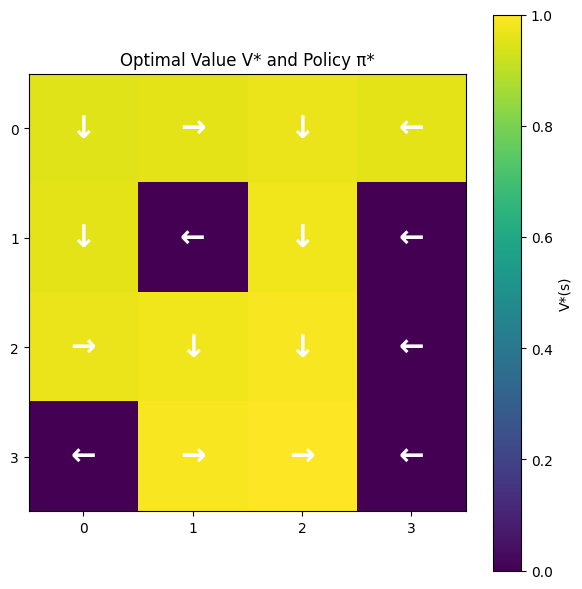

In [ ]:
# Plot V* as a heatmap with the policy arrows overlaid
fig, ax = plt.subplots(figsize=(6, 6))          # create one square plot

# Show V* as a color grid
im = ax.imshow(V_star.reshape(4, 4), cmap="viridis")  # blue→yellow = low→high value
plt.colorbar(im, ax=ax, label="V*(s)")          # color scale

# Overlay arrows for the policy + label each cell
for s in range(n_states):                       # one cell at a time
    row, col = s // 4, s % 4                    # convert state index → (row, col)
    a = policy_star[s]                          # optimal action there
    # Draw the action arrow in white
    ax.text(col, row, arrows[a],
            ha="center", va="center",
            color="white", fontsize=22, fontweight="bold")

# Cosmetic tweaks
ax.set_xticks(range(4))                         # x axis labels
ax.set_yticks(range(4))                         # y axis labels
ax.set_title("Optimal Value V* and Policy π*")  # title
plt.tight_layout()                              # nice spacing
plt.show()                                      # render
